## Optimización Bajo Incertidumbre (IIND 4125)

### Proyecto 2: Programación Estocástica

#### Daniel Velandia, Juan Aguirre y Sofía Acosta

In [1]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [6]:
# Parámetros principales del modelo
SEED_BASE = 123
#INSTANCE = 69
DELTA_U = 0.8 # incremento de capacidad si se refuerza una línea
H_VALUE = 50 # costo de reforzar cada arco
BUDGET = 2500 # presupuesto total
PI = 190 # penalización por energía no servida
ALPHA = 0.95 # nivel CVaR

## 1. Generación de escenarios

In [7]:
# Carga de la red base

def load_edges_from_csv(path_edges: str):
    edges = pd.read_csv(path_edges)
    edges = edges.rename(columns={
        "node_id1": "i",
        "node_id2": "j",
        "b": "c_base",
        "f_max": "U_base"
    })
    edges["e_id"] = np.arange(len(edges))
    return edges

def load_nodes_from_csv(path_nodes: str):
    nodes = pd.read_csv(path_nodes)
    nodes = nodes.rename(columns={"node_id": "node"})
    return nodes

edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

nodes = nodes[nodes["instance"] == INSTANCE].reset_index(drop=True)

#print("Instancia:", INSTANCE)
print("Nodos:", len(nodes))
print("Arcos:", len(edges))
print("Generadores:", nodes["is_generator"].sum())

Nodos: 118
Arcos: 179
Generadores: 18


In [8]:
def build_base_data(nodes, edges):
    nodes_list = nodes["node"].unique().tolist()
    edges_list = edges["e_id"].unique().tolist()

    demand_nodes = nodes[nodes["d"].fillna(0) > 0]["node"].tolist()
    gen_nodes = nodes[nodes["is_generator"] == True]["node"].tolist()

    out_arcs = {
        i: edges[edges["i"] == i]["e_id"].tolist()
        for i in nodes_list
    }

    in_arcs = {
        i: edges[edges["j"] == i]["e_id"].tolist()
        for i in nodes_list
    }

    arc_i = dict(zip(edges["e_id"], edges["i"]))
    arc_j = dict(zip(edges["e_id"], edges["j"]))

    U_base = dict(zip(edges["e_id"], edges["U_base"]))
    H_e = {e: H_VALUE for e in edges_list}

    return {
        "nodes_list": nodes_list,
        "edges_list": edges_list,
        "demand_nodes": demand_nodes,
        "gen_nodes": gen_nodes,
        "in_arcs": in_arcs,
        "out_arcs": out_arcs,
        "arc_i": arc_i,
        "arc_j": arc_j,
        "U_base": U_base,
        "H_e": H_e
    }


base = build_base_data(nodes, edges)

print("Nodos de demanda:", len(base["demand_nodes"]))
print("Nodos generadores:", len(base["gen_nodes"]))
print("Arcos:", len(base["edges_list"]))

Nodos de demanda: 89
Nodos generadores: 18
Arcos: 179


In [11]:
# Generador de escenarios
def sample_one_scenario_W(
    nodes, edges, rng,
    p_crisis=0.15,
    dem_sigma=0.10,
    cost_sigma=0.05,
    p_outage=0.20,
    cap_drop=0.45,
    crisis_cost_mult=1.25,
    correlated_outage_nodes=None,
    correlated_outage_prob=0.80
):
    crisis = rng.random() < p_crisis

    # -----------------------------
    # Demanda
    # -----------------------------
    D = nodes[["node"]].copy()
    D["D_base"] = nodes["d"].fillna(0.0)

    if not crisis:
        mult = rng.normal(1.0, dem_sigma, size=len(D))
        mult = np.clip(mult, 0.0, None)
    else:
        pareto_alpha = 2.0
        mult = 1.0 + rng.pareto(a=pareto_alpha, size=len(D))

    D["D_w"] = D["D_base"] * mult
    D.loc[D["D_base"] == 0, "D_w"] = 0.0

    # -----------------------------
    # Costos operativos
    # -----------------------------
    c = edges[["e_id", "c_base"]].copy()

    if not crisis:
        cost_mult = rng.normal(1.0, cost_sigma, size=len(c))
        cost_mult = np.clip(cost_mult, 0.1, None)
    else:
        cost_mult = np.ones(len(c)) * crisis_cost_mult

    c["c_w"] = c["c_base"] * cost_mult

    # -----------------------------
    # Capacidad efectiva
    # -----------------------------
    U = edges[["e_id", "i", "j", "U_base"]].copy()
    U["U_w"] = U["U_base"]

    outage = rng.random(len(U)) < p_outage
    U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]

    if crisis and correlated_outage_nodes is not None:
        for node in correlated_outage_nodes:
            if rng.random() < correlated_outage_prob:
                mask = (U["i"] == node) | (U["j"] == node)
                U.loc[mask, "U_w"] = 0.0

    # -----------------------------
    # Generación disponible
    # -----------------------------
    G = nodes[["node", "p_max", "is_generator"]].copy()
    G["G_w"] = np.where(G["is_generator"] == True, G["p_max"].fillna(0.0), 0.0)

    if crisis:
        G["G_w"] = 0.85 * G["G_w"]

    return {
        "D": D[["node", "D_w"]],
        "U": U[["e_id", "U_w"]],
        "c": c[["e_id", "c_w"]],
        "G": G[["node", "G_w"]],
        "crisis": crisis
    }

In [13]:
def generate_scenarios_table(nodes, edges, N, seed=123):
    rng = np.random.default_rng(seed)

    gen_nodes = nodes[nodes["is_generator"] == True]["node"].tolist()

    scenarios = []
    for _ in range(N):
        sc = sample_one_scenario_W(
            nodes,
            edges,
            rng,
            correlated_outage_nodes=gen_nodes
        )
        scenarios.append(sc)

    rows_D, rows_U, rows_c, rows_G, rows_p = [], [], [], [], []

    p = 1.0 / N

    for w, sc in enumerate(scenarios, start=1):
        rows_p.append({
            "omega": w,
            "p_omega": p,
            "crisis": sc["crisis"]
        })

        for _, r in sc["D"].iterrows():
            rows_D.append({
                "omega": w,
                "node": int(r["node"]),
                "D_iw": float(r["D_w"])
            })

        for _, r in sc["U"].iterrows():
            rows_U.append({
                "omega": w,
                "e_id": int(r["e_id"]),
                "U_ew": float(r["U_w"])
            })

        for _, r in sc["c"].iterrows():
            rows_c.append({
                "omega": w,
                "e_id": int(r["e_id"]),
                "c_ew": float(r["c_w"])
            })

        for _, r in sc["G"].iterrows():
            rows_G.append({
                "omega": w,
                "node": int(r["node"]),
                "G_iw": float(r["G_w"])
            })

    return (
        pd.DataFrame(rows_D),
        pd.DataFrame(rows_U),
        pd.DataFrame(rows_c),
        pd.DataFrame(rows_G),
        pd.DataFrame(rows_p)
    )

In [12]:
def build_scenario_data(dfD, dfU, dfc, dfG, dfp):
    omegas = dfp["omega"].tolist()

    p_omega = dict(zip(dfp["omega"], dfp["p_omega"]))

    D = {
        (int(r.omega), int(r.node)): float(r.D_iw)
        for _, r in dfD.iterrows()
    }

    U_ew = {
        (int(r.omega), int(r.e_id)): float(r.U_ew)
        for _, r in dfU.iterrows()
    }

    c_ew = {
        (int(r.omega), int(r.e_id)): float(r.c_ew)
        for _, r in dfc.iterrows()
    }

    G_iw = {
        (int(r.omega), int(r.node)): float(r.G_iw)
        for _, r in dfG.iterrows()
    }

    return omegas, p_omega, D, U_ew, c_ew, G_iw

In [14]:
# Prueba escenarios variando N
N_TEST = 10

dfD, dfU, dfc, dfG, dfp = generate_scenarios_table(
    nodes,
    edges,
    N=N_TEST,
    seed=SEED_BASE
)

omegas, p_omega, D, U_ew, c_ew, G_iw = build_scenario_data(
    dfD, dfU, dfc, dfG, dfp
)

print("Escenarios generados:", len(omegas))
print("Suma de probabilidades:", sum(p_omega.values()))
print("Escenarios de crisis:", dfp["crisis"].sum())

C:\Users\sofia\AppData\Local\Temp\ipykernel_37584\688715757.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[575.55 132.75 121.95 127.8  121.95 150.3  143.1   92.25 142.2  141.75
 128.7  121.95 121.5  113.4  136.8  113.4  150.3  142.2  556.2  150.3
 113.85 113.85 121.95 142.2  113.4  100.35 130.05 111.6  142.2  621.9 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_37584\688715757.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[142.2  142.2  121.95 132.75 116.55 143.1  121.95 141.75 121.95  94.5
 122.85 121.5  136.8  125.55 113.4   90.45 240.3  142.2   58.05 113.85
 121.95 140.85 141.75 113.85 121.5  121.95 113.4  109.35 121.95 890.1
 615.6  642.15 113.85]' has dtype in

Escenarios generados: 10
Suma de probabilidades: 0.9999999999999999
Escenarios de crisis: 1


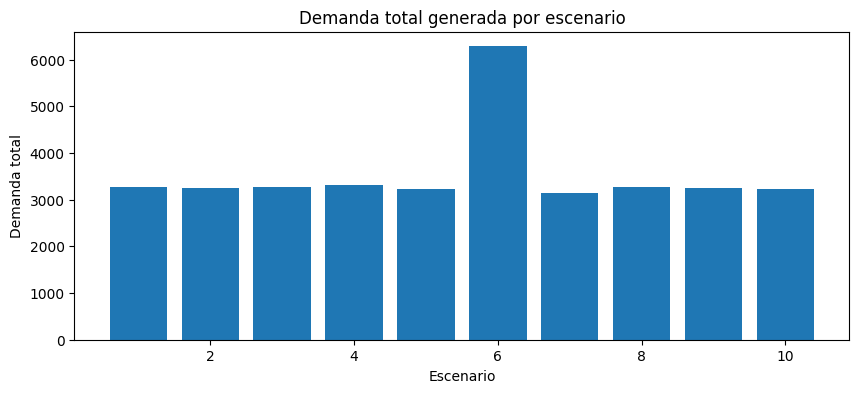

In [16]:
# Comparación de escenarios generados

# Demanda
demanda_total = dfD.groupby("omega")["D_iw"].sum().reset_index()
demanda_total = demanda_total.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(demanda_total["omega"], demanda_total["D_iw"])
plt.title("Demanda total generada por escenario")
plt.xlabel("Escenario")
plt.ylabel("Demanda total")
plt.show()

<Figure size 600x400 with 0 Axes>

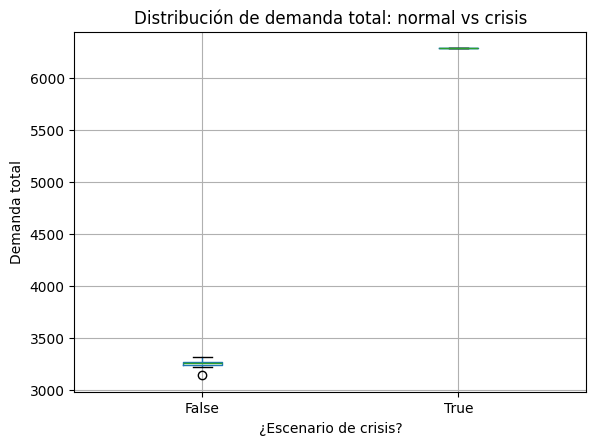

In [17]:
plt.figure(figsize=(6,4))
demanda_total.boxplot(column="D_iw", by="crisis")
plt.title("Distribución de demanda total: normal vs crisis")
plt.suptitle("")
plt.xlabel("¿Escenario de crisis?")
plt.ylabel("Demanda total")
plt.show()

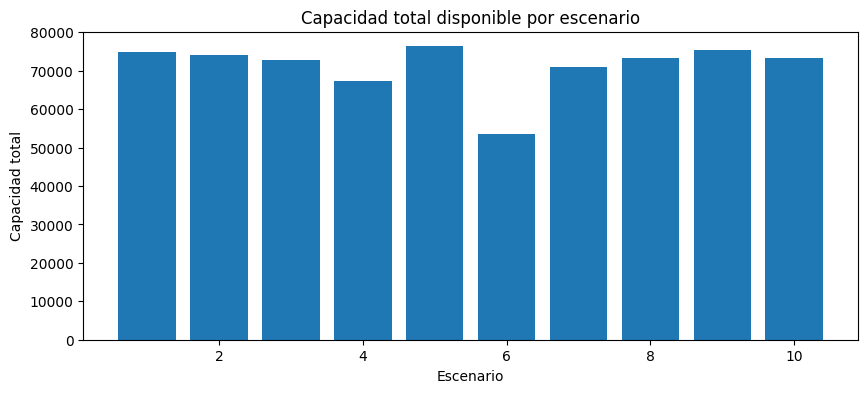

In [18]:
capacidad_total = dfU.groupby("omega")["U_ew"].sum().reset_index()
capacidad_total = capacidad_total.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(capacidad_total["omega"], capacidad_total["U_ew"])
plt.title("Capacidad total disponible por escenario")
plt.xlabel("Escenario")
plt.ylabel("Capacidad total")
plt.show()

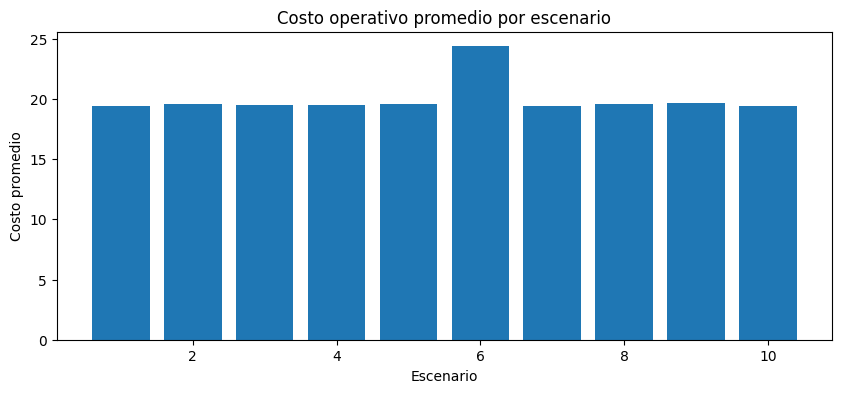

In [19]:
costo_promedio = dfc.groupby("omega")["c_ew"].mean().reset_index()
costo_promedio = costo_promedio.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(costo_promedio["omega"], costo_promedio["c_ew"])
plt.title("Costo operativo promedio por escenario")
plt.xlabel("Escenario")
plt.ylabel("Costo promedio")
plt.show()

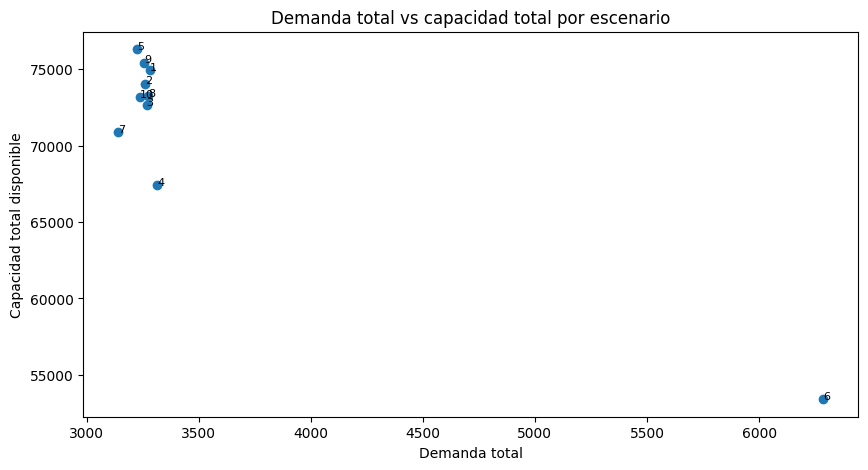

In [20]:
resumen = demanda_total[["omega", "D_iw", "crisis"]].merge(
    capacidad_total[["omega", "U_ew"]],
    on="omega"
)

plt.figure(figsize=(10,5))
plt.scatter(resumen["D_iw"], resumen["U_ew"])

for _, row in resumen.iterrows():
    plt.text(row["D_iw"], row["U_ew"], str(int(row["omega"])), fontsize=8)

plt.title("Demanda total vs capacidad total por escenario")
plt.xlabel("Demanda total")
plt.ylabel("Capacidad total disponible")
plt.show()

In [21]:
resumen["gap_demanda_capacidad"] = resumen["D_iw"] - resumen["U_ew"]

resumen.sort_values("gap_demanda_capacidad", ascending=False)

,omega,D_iw,crisis,U_ew,gap_demanda_capacidad
5,6,6284.562957,True,53403.80,-47119.237043
3,4,3316.238719,False,67427.15,-64110.911281
6,7,3142.044126,False,70885.55,-67743.505874
2,3,3267.633094,False,72647.75,-69380.116906
9,10,3239.187890,False,73167.50,-69928.312110
7,8,3273.348917,False,73246.15,-69972.801083
1,2,3259.165616,False,74054.10,-70794.934384
0,1,3281.241290,False,74929.70,-71648.458710
8,9,3256.239598,False,75422.50,-72166.260402
4,5,3225.075258,False,76316.25,-73091.174742


## 2. Modelo equivalente determinístico

In [22]:
def solve_deterministic_equivalent(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    time_limit=None,
    verbose=True
):
    start = time.time()

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    m = gp.Model("Deterministic_Equivalent")

    if not verbose:
        m.Params.OutputFlag = 0

    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    # Variables de primera etapa
    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")

    # Variables de segunda etapa
    f = m.addVars(omegas, edges_list, lb=0, name="f")
    delta = m.addVars(omegas, demand_nodes, lb=0, name="delta")
    g = m.addVars(omegas, gen_nodes, lb=0, name="g")

    # Presupuesto
    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # Restricciones por escenario
    for w in omegas:

        # Capacidad de arcos
        for e in edges_list:
            m.addConstr(
                f[w, e] <= U_ew[w, e] * (1 + delta_u * h[e]),
                name=f"cap_w{w}_e{e}"
            )

        # Límite generación
        for i in gen_nodes:
            m.addConstr(
                g[w, i] <= G_iw[w, i],
                name=f"gen_w{w}_i{i}"
            )

        # Límite demanda no servida
        for i in demand_nodes:
            m.addConstr(
                delta[w, i] <= D[w, i],
                name=f"delta_w{w}_i{i}"
            )

        # Balance de flujo
        for i in nodes_list:

            inflow = gp.quicksum(f[w, e] for e in in_arcs[i])
            outflow = gp.quicksum(f[w, e] for e in out_arcs[i])

            if i in demand_nodes:
                m.addConstr(
                    inflow - outflow == D[w, i] - delta[w, i],
                    name=f"balance_demand_w{w}_i{i}"
                )

            elif i in gen_nodes:
                m.addConstr(
                    inflow - outflow == -g[w, i],
                    name=f"balance_gen_w{w}_i{i}"
                )

            else:
                m.addConstr(
                    inflow - outflow == 0,
                    name=f"balance_trans_w{w}_i{i}"
                )

    # Función objetivo
    investment_cost = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    expected_operating_cost = gp.quicksum(
        p_omega[w] * gp.quicksum(c_ew[w, e] * f[w, e] for e in edges_list)
        for w in omegas
    )

    expected_ens_cost = gp.quicksum(
        p_omega[w] * pi * gp.quicksum(delta[w, i] for i in demand_nodes)
        for w in omegas
    )

    m.setObjective(
        investment_cost + expected_operating_cost + expected_ens_cost,
        GRB.MINIMIZE
    )

    m.optimize()

    runtime = time.time() - start

    if m.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
        print("Estado del modelo:", m.Status)
        return None

    h_sol = {e: h[e].X for e in edges_list}

    selected_edges = [e for e in edges_list if h_sol[e] > 0.5]

    results = {
        "model": m,
        "objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "selected_edges": selected_edges,
        "investment_cost": sum(H_e[e] * h_sol[e] for e in edges_list),
        "num_selected_edges": len(selected_edges)
    }

    return results

In [ ]:

# Modelo con datos de prueba
de_results = solve_deterministic_equivalent(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    verbose=True
)

print("Objetivo DE:", de_results["objective"])
print("Tiempo:", de_results["runtime"])
print("Costo inversión:", de_results["investment_cost"])
print("Arcos reforzados:", de_results["num_selected_edges"])
print("Lista de arcos reforzados:", de_results["selected_edges"])

Set parameter Username
Set parameter LicenseID to value 2789937
Academic license - for non-commercial use only - expires 2027-03-10
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 5600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 4041 rows, 3039 columns and 9425 nonzeros
Model fingerprint: 0x869f0bfd
Variable types: 2860 continuous, 179 integer (179 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [2e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+00, 1e+04]
Found heuristic solution: objective 675350.01184
Presolve removed 3107 rows and 1515 columns
Presolve time: 0.07s
Presolved: 934 rows, 1524 columns, 3805 nonzeros
Found heuristic solution: objective 589451.09719
Variable types: 1432 continuous, 92 integer (92 binary)

Root relaxation: objective 3.118190e+05, 

In [24]:
edges_plot = edges.copy()
edges_plot["reforzado"] = edges_plot["e_id"].isin(de_results["selected_edges"])

edges_plot[["e_id", "i", "j", "U_base", "reforzado"]].sort_values(
    "reforzado",
    ascending=False
)

,e_id,i,j,U_base,reforzado
94,94,48,68,156,True
34,34,25,29,612,True
113,113,76,81,253,True
69,69,48,53,178,True
106,106,68,76,270,True
...,...,...,...,...,...
66,66,50,51,255,False
67,67,51,52,298,False
68,68,52,53,318,False
70,70,53,54,304,False


In [25]:
def extract_scenario_costs_from_de(de_results, base, omegas, p_omega, c_ew, pi=PI):
    m = de_results["model"]

    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]

    rows = []

    for w in omegas:
        op_cost = 0
        ens_cost = 0

        for e in edges_list:
            var = m.getVarByName(f"f[{w},{e}]")
            op_cost += c_ew[w, e] * var.X

        for i in demand_nodes:
            var = m.getVarByName(f"delta[{w},{i}]")
            ens_cost += pi * var.X

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "operating_cost": op_cost,
            "ens_cost": ens_cost,
            "second_stage_cost": op_cost + ens_cost
        })

    return pd.DataFrame(rows)


df_costs_de = extract_scenario_costs_from_de(
    de_results,
    base,
    omegas,
    p_omega,
    c_ew
)

df_costs_de

,omega,p_omega,operating_cost,ens_cost,second_stage_cost
0,1,0.1,105199.850993,110049.855558,2.152497e+05
1,2,0.1,97516.251568,128031.987252,2.255482e+05
2,3,0.1,102311.232943,130506.507201,2.328177e+05
3,4,0.1,93442.245304,153925.612402,2.473679e+05
4,5,0.1,104303.094922,116135.318049,2.204384e+05
5,6,0.1,67956.029908,978375.248612,1.046331e+06
6,7,0.1,88019.818447,144941.181965,2.329610e+05
7,8,0.1,91117.980091,152281.543983,2.433995e+05
8,9,0.1,101302.737409,127028.997442,2.283317e+05
9,10,0.1,104719.434659,117045.489507,2.217649e+05


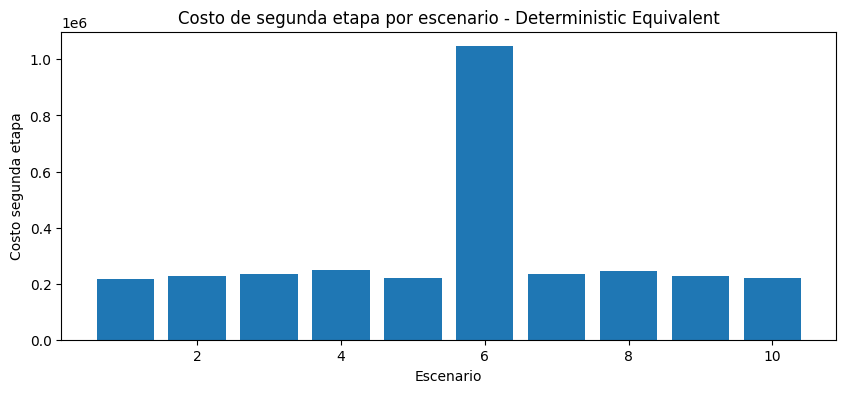

In [26]:
df_costs_plot = df_costs_de.merge(dfp[["omega", "crisis"]], on="omega")

plt.figure(figsize=(10,4))
plt.bar(df_costs_plot["omega"], df_costs_plot["second_stage_cost"])
plt.title("Costo de segunda etapa por escenario - Deterministic Equivalent")
plt.xlabel("Escenario")
plt.ylabel("Costo segunda etapa")
plt.show()